# **Marks Predection Using Simple Linear Regression**

### **Import Library**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

### **Load Dataset**

In [2]:
dataset_path = "exam_marks_data.csv"

df = pd.read_csv(dataset_path)

In [3]:
df.head()

,HoursStudied,ExamMarks
0,0.3,6.29
1,0.3,7.57
2,0.3,9.41
3,0.3,4.87
4,0.3,7.48


### **Dataset Validation**

In [4]:
print("Printing Dataset Shape: ", df.shape)

Printing Dataset Shape:  (25000, 2)


In [5]:
print("Printing Dataset's all Columns: ", df.columns)

Printing Dataset's all Columns:  Index(['HoursStudied', 'ExamMarks'], dtype='str')


In [6]:
print("Printing Dataset's Column Datatype: ", df.columns)

Printing Dataset's Column Datatype:  Index(['HoursStudied', 'ExamMarks'], dtype='str')


In [7]:
print("Printing all null values from Dataset: ")
df.isnull().sum()

Printing all null values from Dataset: 


HoursStudied    0
ExamMarks       0
dtype: int64

In [8]:
print("Printing all Duplicate values from Dataset: ", df.duplicated().sum())

Printing all Duplicate values from Dataset:  146


In [9]:
print("Printing Information about Dataset: ")
df.info()

Printing Information about Dataset: 
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HoursStudied  25000 non-null  float64
 1   ExamMarks     25000 non-null  float64
dtypes: float64(2)
memory usage: 390.8 KB


In [10]:
print("Printing Statistical Summary: ")
df.describe()

Printing Statistical Summary: 


,HoursStudied,ExamMarks
count,25000.000000,25000.000000
mean,25.008162,51.640916
std,14.336566,26.588480
min,0.300000,1.340000
25%,12.440000,28.540000
50%,25.140000,51.650000
75%,37.380000,74.560000
max,50.000000,100.000000


In [11]:
print("Printing Correlation Matrix: ")
df.corr(numeric_only=True)

Printing Correlation Matrix: 


,HoursStudied,ExamMarks
HoursStudied,1.000000,0.997147
ExamMarks,0.997147,1.000000


### **Data Visualization**

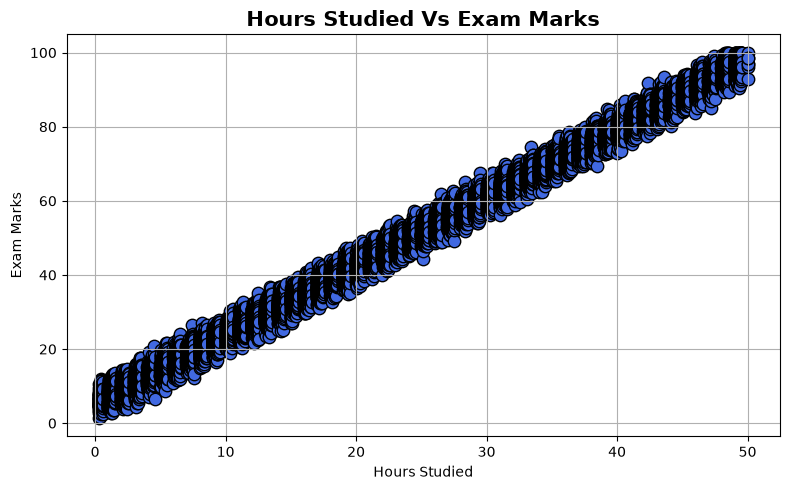

In [12]:
plt.figure(figsize=(8,5))

plt.scatter(
    df[['HoursStudied']],
    df['ExamMarks'],
    color='royalBlue',
    edgecolors='black',
    s=80
)

plt.title("Hours Studied Vs Exam Marks", fontsize=15,fontweight="bold")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Marks")
plt.grid(True)
plt.tight_layout()
plt.show()

### **Marks Distribution**

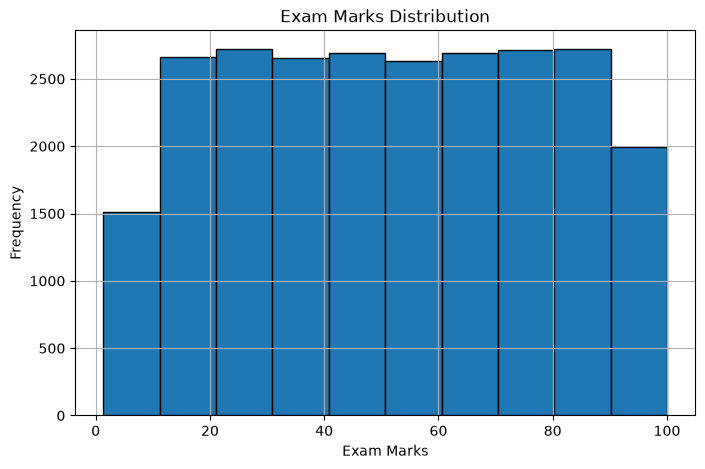

In [13]:
plt.figure(figsize=(8,5))

plt.hist(
    df['ExamMarks'],
    bins=10,
    edgecolor="black"
)

plt.title("Exam Marks Distribution")
plt.xlabel("Exam Marks")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

### **Box Plot**

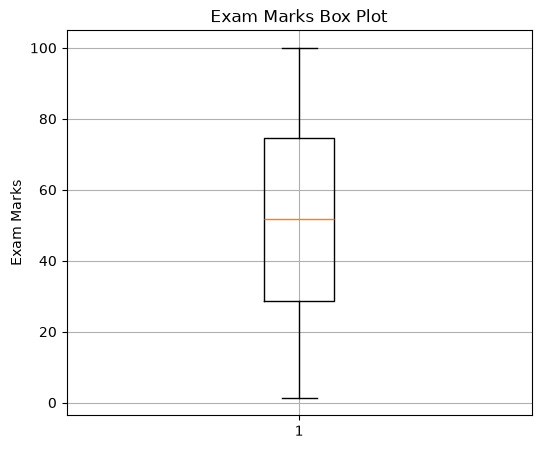

In [14]:
plt.figure(figsize=(6,5))
plt.boxplot(df["ExamMarks"])
plt.title("Exam Marks Box Plot")
plt.ylabel("Exam Marks")
plt.grid(True)
plt.show()

### **Features**

In [15]:
X = df[["HoursStudied"]]
y = df["ExamMarks"]

### **Train Test Split**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("="*60)
print("Dataset Split Summary: ")
print("="*60)

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

Dataset Split Summary: 
X_train: (20000, 1)
X_test : (5000, 1)
y_train: (20000,)
y_test : (5000,)


### **Train Model**

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.85]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['HoursStudied']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.391
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


### **Model Parameters**

In [18]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope    :", slope)
print(f"Intercept:", intercept)

print("="*70)
print(f"Exam Marks = ({slope:2f} * Hours Studied) + {intercept:2f}")
print("="*70)

Slope    : 1.8496709103867375
Intercept: 5.390700345633384
Exam Marks = (1.849671 * Hours Studied) + 5.390700


### **Predictions**

In [23]:
y_pred = model.predict(X_test)

### **Model Evaluations**

In [28]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("="*60)
print("Model Evaluation: ")
print("="*60)
print(f"MAE      : {mae:.2f}")
print(f"MSE      : {mse:.2f}")
print(f"RMSE     : {rmse:.2f}")
print(f"R² Score : {r2*100:.2f}%")

Model Evaluation: 
MAE      : 1.61
MSE      : 4.11
RMSE     : 2.03
R² Score : 99.42%


### **Regression Line**

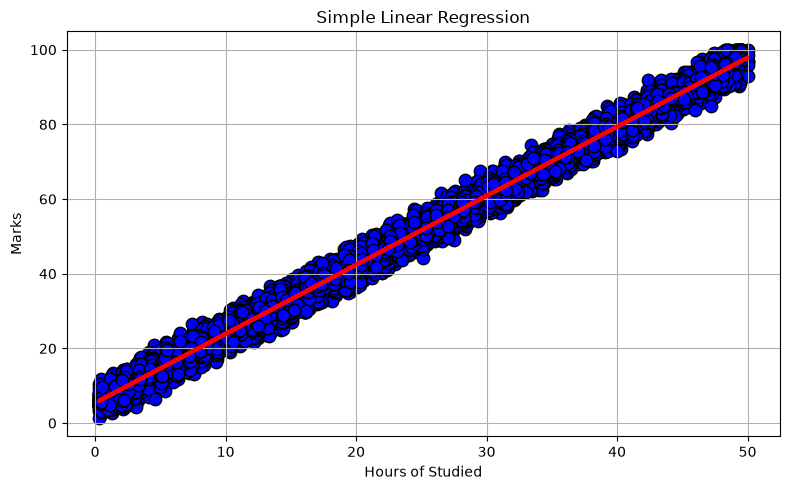

In [33]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_train,
    y_train,
    color='blue',
    edgecolors='black',
    s=80,
    label = "Trainig Data"
)

plt.plot(
    X_train,
    model.predict(X_train),
    color = "red",
    linewidth=3,
    label="Regression Line"
)

plt.title("Simple Linear Regression")
plt.xlabel("Hours of Studied")
plt.ylabel("Marks")
plt.grid(True)
plt.tight_layout()
plt.show()

### **Actual Vs Predicted**

In [38]:
comparison = pd.DataFrame({
    "Experience":X_test.iloc[:,0],
    "Actual Salary":y_test.values,
    "Predicted Salary":y_pred
})

comparison["Residual"]=comparison["Actual Salary"]-comparison["Predicted Salary"]
comparison["Absolute Error"]=comparison["Residual"].abs()
comparison

,Experience,Actual Salary,Predicted Salary,Residual,Absolute Error
6868,13.57,30.78,30.490735,0.289265,0.289265
24016,48.03,95.88,94.230394,1.649606,1.649606
9668,19.33,43.43,41.144839,2.285161,2.285161
13640,27.32,56.18,55.923710,0.256290,0.256290
14018,28.18,58.03,57.514427,0.515573,0.515573
...,...,...,...,...,...
8670,17.35,36.57,37.482491,-0.912491,0.912491
11839,23.57,50.62,48.987444,1.632556,1.632556
4013,8.21,21.17,20.576499,0.593501,0.593501
21147,42.20,82.22,83.446813,-1.226813,1.226813


### **Residual Plot**

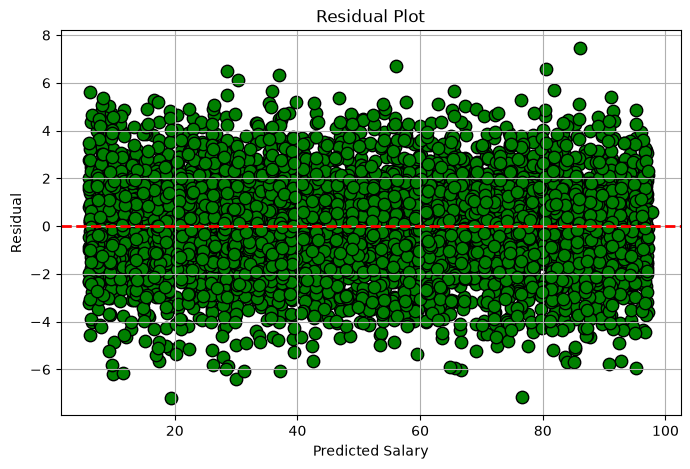

In [39]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_pred,
    comparison["Residual"],
    color="green",
    s=80,
    edgecolors="black"
)

plt.axhline(
    y=0,
    linewidth=2,
    linestyle="--",
    color="red"
)

plt.title("Residual Plot")

plt.xlabel("Predicted Salary")

plt.ylabel("Residual")

plt.grid(True)

plt.show()

### **Predict New Marks**

In [46]:
hoursstudied=float(input("Enter Hours Studied: "))

marks=model.predict([[hoursstudied]])

print()

print(f"Predicted Exam Marks : {marks}")


Predicted Exam Marks : [97.87424586]


In [47]:
df.columns

Index(['HoursStudied', 'ExamMarks'], dtype='str')

### **Final Dashboard**

In [54]:
print("="*70)

print("EXAM MARKS PREDICTION LINEAR REGRESSION SUMMARY")

print("="*70)

print(f"Algorithm            : Simple Linear Regression")
print(f"Dataset              : exam_marks_data.csv")
print(f"Training Samples     : {len(X_train)}")
print(f"Testing Samples      : {len(X_test)}")
print(f"Input Feature        : HoursStudied")
print(f"Target Variable      : ExamMarks")
print(f"Slope                : {model.coef_[0]:.4f}")
print(f"Intercept            : {model.intercept_:.4f}")
print(f"MAE                  : {mae:.2f}")
print(f"MSE                  : {mse:.2f}")
print(f"RMSE                 : {rmse:.2f}")
print(f"R² Score             : {r2*100:.2f}%")
print(f"Best Fit Line        : Exam Marks = ({slope:.2f} * HoursStudied) + {intercept:.2f}")

EXAM MARKS PREDICTION LINEAR REGRESSION SUMMARY
Algorithm            : Simple Linear Regression
Dataset              : exam_marks_data.csv
Training Samples     : 20000
Testing Samples      : 5000
Input Feature        : HoursStudied
Target Variable      : ExamMarks
Slope                : 1.8497
Intercept            : 5.3907
MAE                  : 1.61
MSE                  : 4.11
RMSE                 : 2.03
R² Score             : 99.42%
Best Fit Line        : Exam Marks = (1.85 * HoursStudied) + 5.39
